# Lab 2 - Artificial Intelligence (COMP3742)
Student Name: Oliver Wuttke

Student FAN: WUTT0019

File: lab2_questions.ipynb

Date: 07-08-2026

Description: Python notebook for entirety of lab 2 questions (Iris dataset)

In [3]:
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score
from sklearn.tree import export_graphviz

In [4]:
# Retrieve the dataset and look at the feature names
iris = fetch_ucirepo(id=53)

X = iris.data.features
Y = iris.data.targets

print(iris.variables)

           name     role         type demographic  \
0  sepal length  Feature   Continuous        None   
1   sepal width  Feature   Continuous        None   
2  petal length  Feature   Continuous        None   
3   petal width  Feature   Continuous        None   
4         class   Target  Categorical        None   

                                         description units missing_values  
0                                                NaN    cm             no  
1                                                NaN    cm             no  
2                                                NaN    cm             no  
3                                                NaN    cm             no  
4  class of iris plant: Iris Setosa, Iris Versico...   NaN             no  


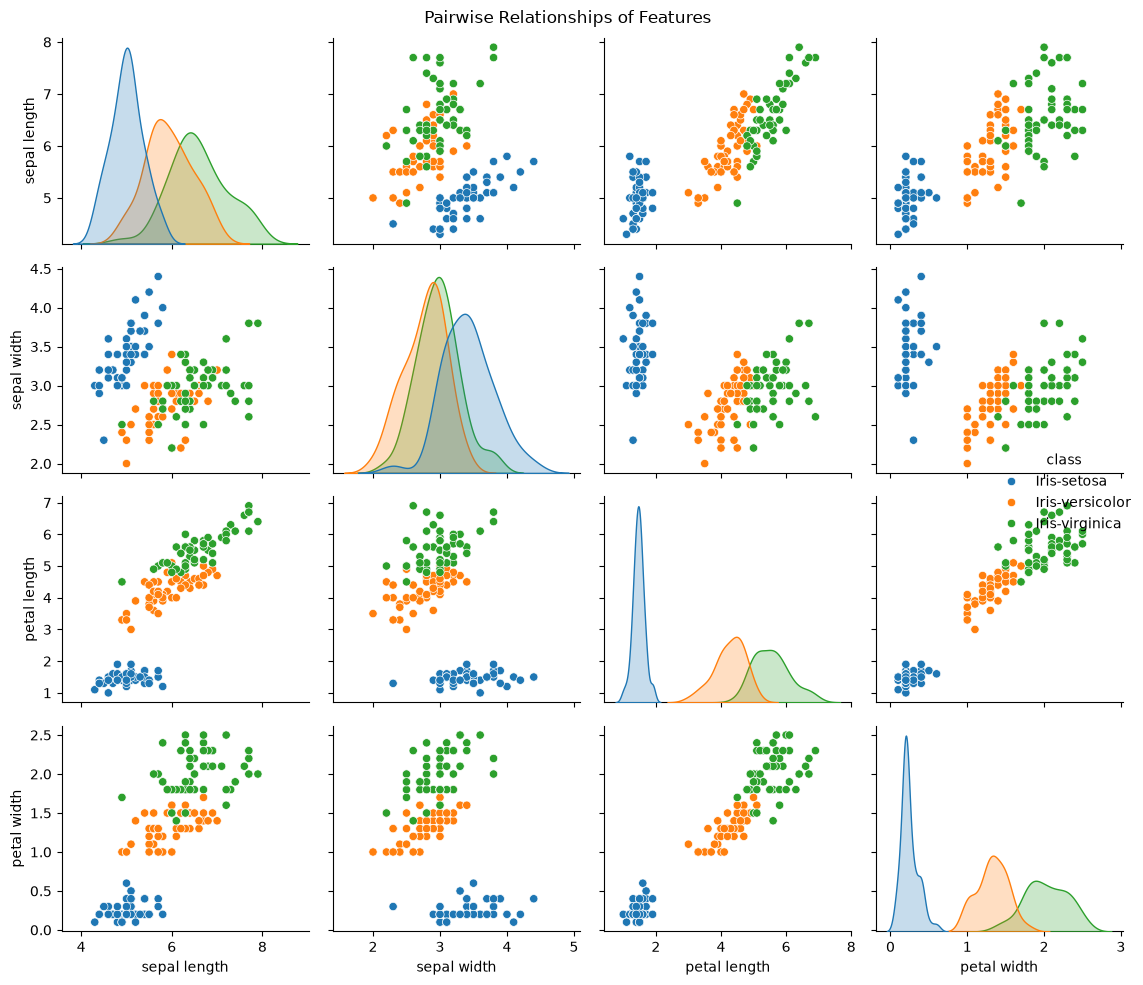

In [5]:
# Plotting pairwise relationships
df = pd.concat([iris.data.features, iris.data.targets], axis=1)

sns.pairplot(df, hue='class')
plt.suptitle('Pairwise Relationships of Features')
plt.tight_layout()
plt.show()

In [6]:
# Train decision tree classifier (no hyperparam tuning)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)

# Make prediction on test set and print accuracy
dtc_predict = dtc.predict(X_test)

accuracy = accuracy_score(y_test, dtc_predict)
print(f"Prediction Accuracy: {accuracy:.2f}")

Prediction Accuracy: 1.00


In [7]:
# Use graphviz to visualize the decision tree model
os.environ['PATH'] += os.pathsep + '/opt/homebrew/Cellar/graphviz'

dot_data = export_graphviz(
    dtc,
    out_file=None,
    feature_names=X.columns,
    class_names=['Iris Setosa', 'Iris Versicola', 'Iris Virginica'],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph.render("decision_tree_iris")
graph.view()

'decision_tree_iris.pdf'

In [10]:
# Grid search cross validation for finding optimal hyperparameters
hyperparam_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 10, 20, 30],
    'max_leaf_nodes': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [4, 10, 20, 50],
    'class_weight': [None, 'balanced'],
    'max_features': [None, 'sqrt', 'log2']
}

dtc_gs = DecisionTreeClassifier()
grid_search = GridSearchCV(estimator=dtc_gs, param_grid=hyperparam_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best Hyper-parameters: ", grid_search.best_params_)
print("Best Score: ", grid_search.best_score_)

Best Hyper-parameters:  {'class_weight': None, 'criterion': 'gini', 'max_depth': 30, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best Score:  0.9619047619047618


In [11]:
# See test set accuracy
gs_predict = grid_search.predict(X_test)
gs_accuracy = accuracy_score(y_test, gs_predict)

print(f"Grid Search Cross-Validation Accuracy: {gs_accuracy:.2f}")

Grid Search Cross-Validation Accuracy: 0.93
